In [7]:
name = input("Enter your name: ")

vowels = "aeiou"
count = 0

for letter in name.lower():
    if letter in vowels:
        print(letter)
        count += 1

print("Number of vowels:", count)
for letter in vowels:
    print("the number of", letter, "is: ", name.count(letter))

Enter your name:  Lakshin


a
i
Number of vowels: 2
the number of a is:  1
the number of e is:  0
the number of i is:  1
the number of o is:  0
the number of u is:  0


In [8]:
for i in range(len(name)):
    for j in range(i+1):
        print(name[j], end=" ")
    print()
        

L 
L a 
L a k 
L a k s 
L a k s h 
L a k s h i 
L a k s h i n 


In [10]:
def pascal(n, r):
    if r == 0 or r == n:
        return 1
    else:
        return pascal(n-1, r-1) + pascal(n-1, r)

rows = int(input("Enter number of rows: "))

for i in range(rows):
    for j in range(i + 1):
        print(pascal(i, j), end=" ")
    print()

Enter number of rows:  6


1 
1 1 
1 2 1 
1 3 3 1 
1 4 6 4 1 
1 5 10 10 5 1 


In [11]:
import pandas as pd
pd.DataFrame([[2,3],[5,6],[8,9]],
   index = ['cobra','viper','sidewinder'],
   columns = ['max_speed','shield'])          


,max_speed,shield
cobra,2,3
viper,5,6
sidewinder,8,9


In [1]:
# ================================
# 1. Import Libraries
# ================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, roc_auc_score, classification_report, roc_curve

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

from imblearn.over_sampling import SMOTE

from xgboost import XGBClassifier


# ================================
# 2. Load Dataset
# ================================

df = pd.read_csv(r"D:\AU files\Sem 6\UCI_Credit_Card.csv\UCI_Credit_Card.csv")

print(df.head())
print(df.info())


# ================================
# 3. Basic Cleaning
# ================================

# Rename target column for simplicity
df.rename(columns={"default.payment.next.month": "default"}, inplace=True)

# Drop ID column
df.drop("ID", axis=1, inplace=True)


# ================================
# 4. Handle Categorical Variables
# ================================

categorical_cols = ["SEX", "EDUCATION", "MARRIAGE"]

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)


# ================================
# 5. Feature Scaling
# ================================

scaler = StandardScaler()

num_cols = [
    'LIMIT_BAL','AGE','BILL_AMT1','BILL_AMT2','BILL_AMT3',
    'BILL_AMT4','BILL_AMT5','BILL_AMT6',
    'PAY_AMT1','PAY_AMT2','PAY_AMT3',
    'PAY_AMT4','PAY_AMT5','PAY_AMT6'
]

df[num_cols] = scaler.fit_transform(df[num_cols])


# ================================
# 6. Train-Test Split
# ================================

X = df.drop("default", axis=1)
y = df["default"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# ================================
# 7. Handle Class Imbalance (SMOTE)
# ================================

smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

print("After SMOTE:", np.bincount(y_train))


# ================================
# 8. Train Models
# ================================

# Logistic Regression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)


# Random Forest
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)


# XGBoost
xgb_model = XGBClassifier(eval_metric='logloss')
xgb_model.fit(X_train, y_train)


# Neural Network
nn_model = MLPClassifier(hidden_layer_sizes=(64,32), max_iter=300)
nn_model.fit(X_train, y_train)


# ================================
# 9. Evaluation Function
# ================================

def evaluate_model(model, X_test, y_test):

    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:,1]

    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    roc = roc_auc_score(y_test, prob)

    print("Precision:", precision)
    print("Recall:", recall)
    print("ROC-AUC:", roc)

    print("\nClassification Report")
    print(classification_report(y_test, pred))


# ================================
# 10. Evaluate All Models
# ================================

print("Logistic Regression")
evaluate_model(log_model, X_test, y_test)

print("\nRandom Forest")
evaluate_model(rf_model, X_test, y_test)

print("\nXGBoost")
evaluate_model(xgb_model, X_test, y_test)

print("\nNeural Network")
evaluate_model(nn_model, X_test, y_test)


# ================================
# 11. Plot ROC Curve
# ================================

def plot_roc(model):

    prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, prob)

    plt.plot(fpr, tpr, label=model.__class__.__name__)

plt.figure()

plot_roc(log_model)
plot_roc(rf_model)
plot_roc(xgb_model)
plot_roc(nn_model)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

ModuleNotFoundError: No module named 'imblearn'

First 5 rows:
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None

Missing Values:
age         0
sex         0
bmi         0
chi

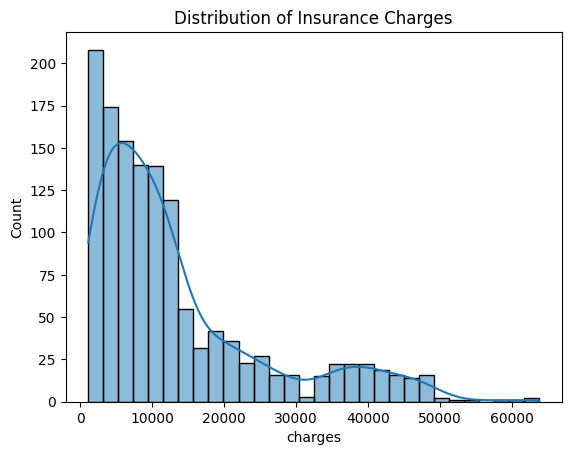


Model Performance:
RMSE: 5799.587091438356
R2 Score: 0.7833463107364539


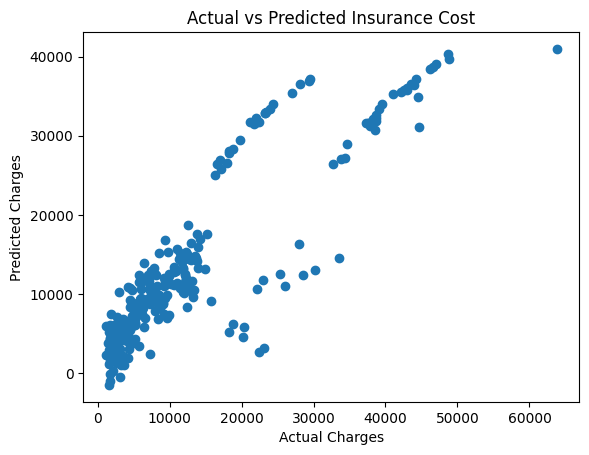

In [2]:
# Medical Insurance Cost Prediction

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Load dataset
df = pd.read_csv(r"D:\AU files\Sem 6\insurance.csv")

# Show first rows
print("First 5 rows:")
print(df.head())

# Dataset info
print("\nDataset Info:")
print(df.info())

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Visualization
plt.figure()
sns.histplot(df["charges"], kde=True)
plt.title("Distribution of Insurance Charges")
plt.show()

# Encode categorical variables
le = LabelEncoder()
df["sex"] = le.fit_transform(df["sex"])
df["smoker"] = le.fit_transform(df["smoker"])
df["region"] = le.fit_transform(df["region"])

# Features and target
X = df.drop("charges", axis=1)
y = df["charges"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluation
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\nModel Performance:")
print("RMSE:", rmse)
print("R2 Score:", r2)

# Actual vs Predicted plot
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Insurance Cost")
plt.show()

First 5 rows:
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None

Missing Values:
age         0
sex         0
bmi         0
chi

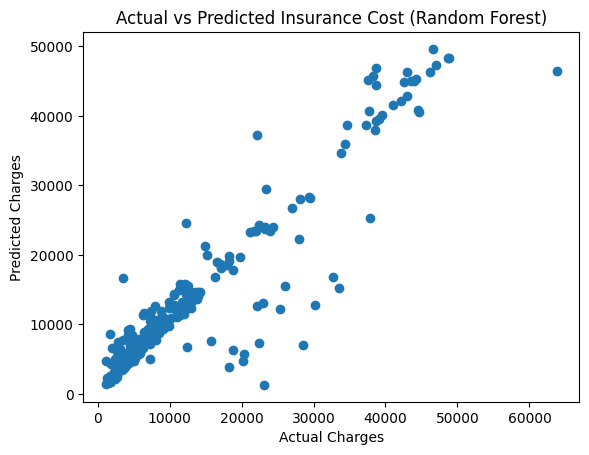

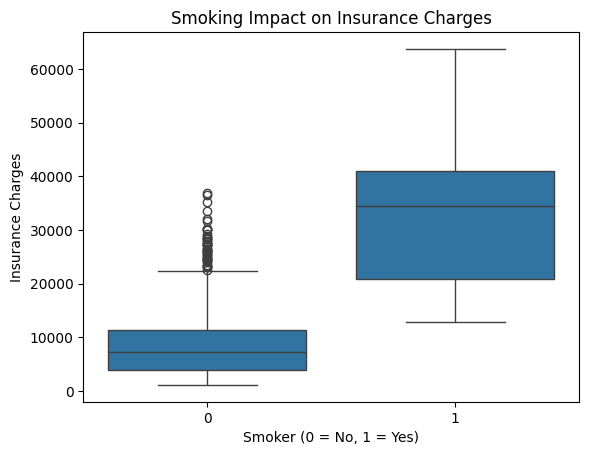

In [3]:
# Medical Insurance Cost Prediction

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Load dataset
df = pd.read_csv(r"D:\AU files\Sem 6\insurance.csv")

# Display dataset
print("First 5 rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())


# Encode categorical variables
le = LabelEncoder()

df["sex"] = le.fit_transform(df["sex"])
df["smoker"] = le.fit_transform(df["smoker"])
df["region"] = le.fit_transform(df["region"])


# Normalize BMI
scaler = StandardScaler()
df["bmi"] = scaler.fit_transform(df[["bmi"]])


# Features and target
X = df.drop("charges", axis=1)
y = df["charges"]


# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# =========================
# Model 1: Linear Regression
# =========================
lr = LinearRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_mae = mean_absolute_error(y_test, lr_pred)


# =========================
# Model 2: Random Forest
# =========================
rf = RandomForestRegressor()
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_mae = mean_absolute_error(y_test, rf_pred)


# =========================
# Model 3: Gradient Boosting
# =========================
gb = GradientBoostingRegressor()
gb.fit(X_train, y_train)

gb_pred = gb.predict(X_test)

gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))
gb_mae = mean_absolute_error(y_test, gb_pred)


# Print results
print("\nModel Performance")

print("\nLinear Regression")
print("RMSE:", lr_rmse)
print("MAE:", lr_mae)

print("\nRandom Forest")
print("RMSE:", rf_rmse)
print("MAE:", rf_mae)

print("\nGradient Boosting")
print("RMSE:", gb_rmse)
print("MAE:", gb_mae)


# Visualization: Actual vs Predicted (Best model example)
plt.figure()
plt.scatter(y_test, rf_pred)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Insurance Cost (Random Forest)")
plt.show()


# Insight: Smoking impact on insurance cost
plt.figure()
sns.boxplot(x="smoker", y="charges", data=df)
plt.title("Smoking Impact on Insurance Charges")
plt.xlabel("Smoker (0 = No, 1 = Yes)")
plt.ylabel("Insurance Charges")
plt.show()